<a href="https://colab.research.google.com/github/aabyyaann/Practical-Linear-Algebra-for-Data-Science/blob/main/Chapter11_General_Linear_Models_and_Least_Squares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11 — General Linear Models and Least Squares

## Tujuan Chapter

Pada chapter ini kita mempelajari:

1. General Linear Model (GLM)
2. Least Squares Solution
3. Solusi sistem overdetermined
4. Residual dan error
5. Geometri least squares
6. Normal Equation
7. Least Squares menggunakan QR Decomposition
8. Aplikasi regresi linear sederhana

Konsep least squares merupakan salah satu fondasi terpenting dalam:

- Data Science
- Machine Learning
- Artificial Intelligence
- Signal Processing
- Statistics
- Scientific Computing

Sebagian besar algoritma regresi sebenarnya merupakan implementasi dari prinsip least squares.

# Ringkasan Teori

## 1. General Linear Model (GLM)

General Linear Model ditulis sebagai:

\[
Ax=b
\]

dengan:

- A = design matrix
- x = parameter yang ingin dicari
- b = data observasi

Tujuan GLM adalah mencari nilai parameter \(x\).

---

## 2. Exact Solution

Jika:

\[
Ax=b
\]

memiliki solusi tepat, maka:

\[
x=A^{-1}b
\]

Namun pada banyak kasus nyata:

- data mengandung noise
- jumlah persamaan lebih banyak daripada jumlah parameter

sehingga solusi eksak sering tidak ada.

---

## 3. Least Squares

Least Squares mencari solusi yang meminimalkan error:

\[
||Ax-b||^2
\]

atau:

\[
\min_x ||Ax-b||^2
\]

---

## 4. Normal Equation

Solusi least squares diberikan oleh:

\[
A^TAx=A^Tb
\]

dan

\[
x=(A^TA)^{-1}A^Tb
\]

jika \(A^TA\) invertible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# 1. Membentuk General Linear Model

Kita mulai dari sistem linear sederhana:

\[
Ax=b
\]

dengan matriks A dan vektor b yang diketahui.

In [2]:
A = np.array([
    [2.,1.],
    [1.,3.]
])

b = np.array([
    5.,
    6.
])

print("A =")
print(A)

print("\nb =")
print(b)

A =
[[2. 1.]
 [1. 3.]]

b =
[5. 6.]


# 2. Solusi Exact

Karena A berbentuk matriks persegi dan memiliki invers, kita dapat memperoleh solusi eksak menggunakan:

\[
x=A^{-1}b
\]

In [3]:
x = np.linalg.inv(A) @ b

print("Solusi exact:")
print(x)

Solusi exact:
[1.8 1.4]


## Verifikasi

Mari kita cek apakah:

\[
Ax=b
\]

benar-benar terpenuhi.

In [4]:
print("Ax =")
print(A @ x)

print("\nb =")
print(b)

Ax =
[5. 6.]

b =
[5. 6.]


# 3. Sistem Overdetermined

Dalam dunia nyata jumlah observasi sering lebih banyak dibanding jumlah parameter.

Contoh:

- 5 observasi
- 2 parameter

Sistem seperti ini disebut:

## Overdetermined System

Biasanya tidak memiliki solusi eksak.

In [5]:
A = np.array([
    [1.,1.],
    [1.,2.],
    [1.,3.],
    [1.,4.],
    [1.,5.]
])

b = np.array([
    1.,
    2.,
    2.5,
    4.,
    5.
])

print("Shape A:", A.shape)
print("Shape b:", b.shape)

Shape A: (5, 2)
Shape b: (5,)


# 4. Apakah solusi exact ada?

Kita coba menyelesaikan sistem menggunakan inverse.

Karena matriks tidak persegi, inverse tidak dapat digunakan.

In [6]:
try:
    np.linalg.inv(A)
except Exception as e:
    print(e)

Last 2 dimensions of the array must be square


## Kesimpulan

Untuk sistem overdetermined:

\[
A^{-1}
\]

tidak tersedia.

Kita memerlukan metode Least Squares.

# 5. Least Squares dengan NumPy

NumPy menyediakan fungsi:

```python
np.linalg.lstsq()

In [7]:
x_ls, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

print("Parameter Least Squares:")
print(x_ls)

Parameter Least Squares:
[-0.1  1. ]


# Interpretasi Parameter

Model yang diperoleh:

\[
y=\beta_0+\beta_1x
\]

dengan:

- β₀ = intercept
- β₁ = slope

In [8]:
beta0 = x_ls[0]
beta1 = x_ls[1]

print("Intercept =", beta0)
print("Slope     =", beta1)

Intercept = -0.10000000000000084
Slope     = 0.9999999999999999


# 6. Prediksi Menggunakan Model

Kita hitung:

\[
\hat b = Ax
\]

yang merupakan hasil prediksi model.

In [9]:
b_hat = A @ x_ls

print(b_hat)

[0.9 1.9 2.9 3.9 4.9]


# 7. Visualisasi Hasil Fitting

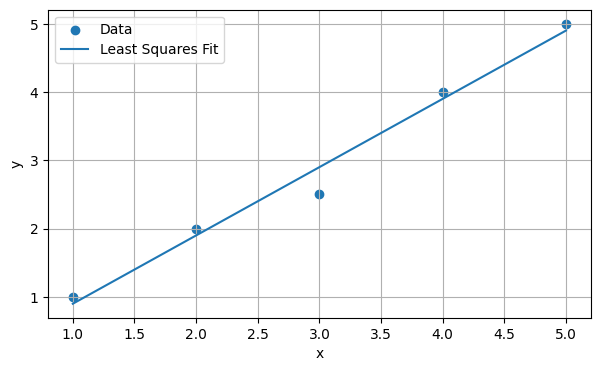

In [10]:
x_data = np.arange(1,6)

plt.figure(figsize=(7,4))
plt.scatter(x_data,b,label="Data")
plt.plot(x_data,b_hat,label="Least Squares Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 8. Residual

Residual adalah selisih antara data aktual dan prediksi:

\[
r=b-\hat b
\]

Residual menunjukkan error model.

In [11]:
residual = b - b_hat

print("Residual:")
print(residual)

Residual:
[ 0.1  0.1 -0.4  0.1  0.1]


# 9. Besar Error

Least Squares meminimalkan:

\[
||r||^2
\]

atau jumlah kuadrat residual.

In [12]:
sse = np.sum(residual**2)

print("Sum Squared Error =", sse)

Sum Squared Error = 0.19999999999999984


# 10. Normal Equation

Least Squares memiliki solusi analitik:

\[
x=(A^TA)^{-1}A^Tb
\]

yang disebut Normal Equation.

In [13]:
ATA = A.T @ A
ATb = A.T @ b

x_normal = np.linalg.inv(ATA) @ ATb

print(x_normal)

[-0.1  1. ]


## Verifikasi

Bandingkan dengan hasil np.linalg.lstsq().

In [14]:
print("Least Squares:")
print(x_ls)

print("\nNormal Equation:")
print(x_normal)

Least Squares:
[-0.1  1. ]

Normal Equation:
[-0.1  1. ]


# 11. Mengapa Least Squares Bekerja?

Least Squares memilih parameter yang membuat residual sekecil mungkin.

Secara geometri:

\[
Ax
\]

merupakan proyeksi vektor b ke ruang kolom (column space) matriks A.

In [15]:
print("Residual:")
print(residual)

print("\nNorm residual:")
print(np.linalg.norm(residual))

Residual:
[ 0.1  0.1 -0.4  0.1  0.1]

Norm residual:
0.44721359549995776


# 12. Sifat Orthogonal Residual

Pada solusi least squares:

\[
A^T r = 0
\]

Residual selalu orthogonal terhadap seluruh kolom A.

In [16]:
check = A.T @ residual

print(check)

[0. 0.]


## Hasil

Nilai mendekati nol menunjukkan bahwa residual orthogonal terhadap column space matriks A.

# 13. Least Squares Menggunakan QR Decomposition

Dari chapter sebelumnya:

\[
A=QR
\]

maka:

\[
Rx=Q^Tb
\]

Pendekatan ini lebih stabil secara numerik dibanding normal equation.

In [17]:
Q,R = np.linalg.qr(A)

print("Q =")
print(Q)

print("\nR =")
print(R)

Q =
[[-0.4472 -0.6325]
 [-0.4472 -0.3162]
 [-0.4472  0.    ]
 [-0.4472  0.3162]
 [-0.4472  0.6325]]

R =
[[-2.2361 -6.7082]
 [ 0.      3.1623]]


# 14. Menghitung Solusi dengan QR

In [18]:
x_qr = np.linalg.solve(R, Q.T @ b)

print("Solusi QR:")
print(x_qr)

Solusi QR:
[-0.1  1. ]


## Verifikasi

Bandingkan seluruh metode.

In [19]:
print("Least Squares:")
print(x_ls)

print("\nNormal Equation:")
print(x_normal)

print("\nQR:")
print(x_qr)

Least Squares:
[-0.1  1. ]

Normal Equation:
[-0.1  1. ]

QR:
[-0.1  1. ]


# 15. Contoh Regresi Linear Sederhana

In [20]:
x_data = np.array([1,2,3,4,5,6])
y_data = np.array([2,4,5,4,5,7])

A_reg = np.column_stack([
    np.ones(len(x_data)),
    x_data
])

print(A_reg)

[[1. 1.]
 [1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]]


In [21]:
coef, *_ = np.linalg.lstsq(A_reg, y_data, rcond=None)

print("Intercept =", coef[0])
print("Slope =", coef[1])

Intercept = 1.7999999999999992
Slope = 0.771428571428572


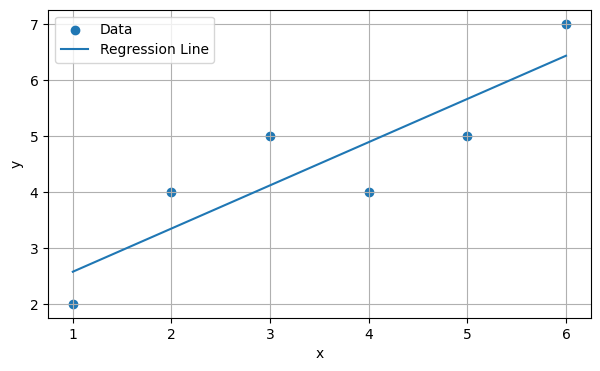

In [22]:
y_pred = A_reg @ coef

plt.figure(figsize=(7,4))
plt.scatter(x_data,y_data,label="Data")
plt.plot(x_data,y_pred,label="Regression Line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Interpretasi

Least Squares berhasil menemukan garis yang paling sesuai dengan data.

Tujuannya bukan melewati semua titik, tetapi meminimalkan total kuadrat error.